# Blair and Lacy Index

Blair and Lacy index measures dispersion between responses in a survey. It is normalized to 0 - 1 limits. Values closer to 0 mean that dispersion is low, responses are falling into one category (the maximum concentration of responses). Values falling into 2 extremes are dispersed, the concentration is low.

Index returns three values:

- `index` - core index value, used in most cases when we analyze single distribution. This index is more sensitive to the changes in the responses distribution when dispersion is high.
- `index_sqrt` - where we take one minus the square root of concentration measure. This index is more sensitive to the changes in the responses distribution when dispersion is low.
- `min_dispersion` - minimum possible dispersion.

**Bibliography**

```
Blair J, Lacy M G. (2000): Statistics of ordinal variation, Sociological Methods and Research 28(251); 251-280
```


## San Francisco City Survey data

This dataset contains processed responses from the `San Francisco City Survey Data` - `https://data.sfgov.org/d/nufj-bfbw`

### Official description

```text
The City Survey asks residents to indicate their usage and satisfaction with city services and infrastructure like libraries, Muni, public safety, and street cleanliness. The City Survey was conducted every year from 1996 to 2004, and biennially from 2005 onward. The City Survey was not conducted in 2019 due to the COVID-19 pandemic, and resumed in 2023. Survey methodology was changed in 2015 from a mail to a phone survey, and expanded to include in-person and online options in 2023.

Comparisons to previous years should be interpreted with caution. Results should be weighted using the column "weight" in order to adjust for demographic differences between the City Survey sample and San Francisco's population. Please note that survey results were originally reported as unweighted until 1997. From 1997 onward, all City Survey results were reweighted with the exception of data from 2011. For ease of use, the column "weight" has been coded with a value of one for these years.

A code book is also attached to this dataset under About > Attachments. Neighborhood and Zip Code data have been hidden from this data set and are only available upon special request to citysurvey@sfgov.org.

For more information regarding San Francisco City Survey 1996-2023 Database,  please visit the City Survey website at https://sf.gov/citysurvey or contact the San Francisco Controller's Office at citysurvey@sfgov.org.
```

### Preprocessing steps

1. Leave columns `['BOSdistrict', 'general_rate', 'muni_rate', 'covid_response']`
2. Drop `NaN` based on the column `'BOSdistrict'`
3. Divide dataset into 3 subsets with non-nan rows, with two columns: `'BOSdistrict'` and one of the following: `'general_rate', 'muni_rate', 'covid_response'`
4. Store `'general_rate', 'muni_rate', 'covid_response'` datasets as csv files
5. Use `'general_rate'` in tutorial.

**Warning**: rates haven't been weighted as is described!

### Citation

```
San Francisco City Survey Data. City Management and Ethics. https://data.sfgov.org/api/views/nufj-bfbw. Issued: 2023-04-11
```

In [4]:
# Imports

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from surveypie.blair_lacy_index import bl_index
from surveypie.core import info

# Data loading and preparation

In [5]:
df = pd.read_csv('clean-san-francisco-data/processed/general_rate.csv')

### Data exploration

Using `info()` function we can check the basic ordinal statistics: the frequency and ratio of indicator's occurrence in the dataset.

The most common indicator is `3`, followed by `4`. The least common indicator is `1`, followed by `6`.

In [6]:
# Plot and visualize input data

info(df['general_rate'], indicators=range(1, 6))

,frequency,ratio %,cumulative
indicator,,,
1.0,1325,4.265250,0.042653
2.0,3649,11.746338,0.160116
3.0,13385,43.087075,0.590987
4.0,11014,35.454692,0.945534
5.0,1692,5.446644,1.000000


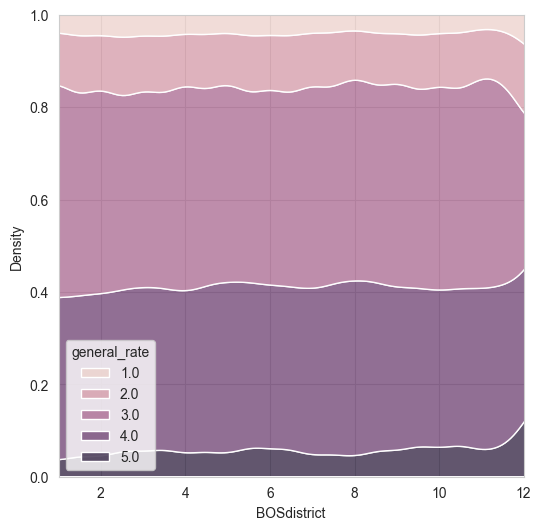

In [7]:
f, ax = plt.subplots(figsize=(6, 6))
sns.kdeplot(data=df, hue='general_rate', x='BOSdistrict', multiple="fill")
ax.set_xlim((1,12))
plt.show()

<Axes: xlabel='BOSdistrict', ylabel='general_rate'>

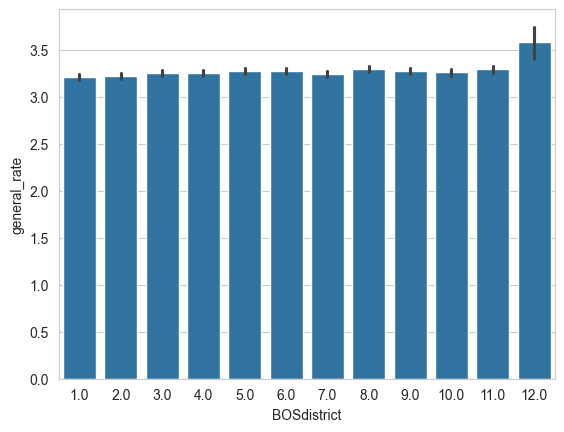

In [8]:
sns.barplot(data=df, y='general_rate', x='BOSdistrict')

It is hard to guess how large is dispersion looking at responses in each district, but we can be sure that there are differences between district 12 and other districts.

## Blair and Lacy Index

Blair and Lacy Index is calculated using `bl_index()` function. It takes two parameters:

- `categories` - ordered list of possible responses
- `responses` - dataset with all responses

The function returns `BlairLacyIndex` object that has three interesting attributes described in the beginning of the notebook.

In [9]:
# Statistics and calculations

# All districts

unique_categories = [1, 2, 3, 4, 5]

bl_sf = bl_index(
    categories=unique_categories,
    responses=df['general_rate']
)

# District 5

bl_sf5 = bl_index(
    categories=unique_categories,
    responses=df['general_rate'][df['BOSdistrict'] == 5]
)

# District 12

bl_sf12 = bl_index(
    categories=unique_categories,
    responses=df['general_rate'][df['BOSdistrict'] == 12]
)

In [10]:
print(f'Blair and Lacy Index - all districts > {bl_sf.index}')
print(f'Blair and Lacy Index - district 5 > {bl_sf5.index}')
print(f'Blair and Lacy Index - district 12 > {bl_sf12.index}')

Blair and Lacy Index - all districts > 0.4685333351778276
Blair and Lacy Index - district 5 > 0.4682372659807724
Blair and Lacy Index - district 12 > 0.3925333333333333


In [11]:
print(f'Blair and Lacy Index - all districts - sqrt > {bl_sf.index_sqrt}')
print(f'Blair and Lacy Index - district 5 - sqrt > {bl_sf5.index_sqrt}')
print(f'Blair and Lacy Index - district 12 - sqrt > {bl_sf12.index_sqrt}')

Blair and Lacy Index - all districts - sqrt > 0.27098239745382524
Blair and Lacy Index - district 5 - sqrt > 0.2707793653363698
Blair and Lacy Index - district 12 - sqrt > 0.22059852023064086


## Summary

What does it mean that index has value **0.47**? The responses dispersion is 47% of the maximal possible dispersion - the state when all responses are equally distributed along each category. Using this metrics we can say, that there are differences between categories.

Differences between categories are better pronounced for *district 12* because it has higher concentration of responses within a single class (check 4-th grade). Plot below shows comparison of responses ratio for all districts and district 12.

<Axes: xlabel='indicator', ylabel='ratio %'>

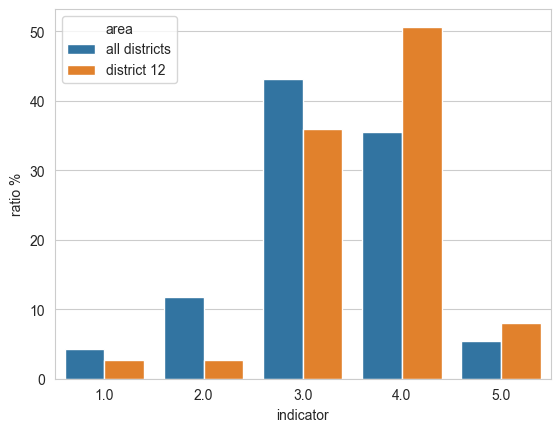

In [18]:
info_general = info(df['general_rate'], indicators=range(1, 6))
info_general['area'] = 'all districts'

info_12 = info(df['general_rate'][df['BOSdistrict'] == 12], indicators=range(1, 6))
info_12['area'] = 'district 12'

info_merged = pd.concat([info_general, info_12])
info_merged.reset_index(inplace=True)
sns.barplot(info_merged, x='indicator', y='ratio %', hue='area')

### Square root or index in the base form?

You may ask yourself, why does the package implement the square root of the index? Following the publication, when we compare a series of ordinal measurements, or the dispersion change over time, then we can use base index or square root of it. Experiments performed by index authors have shown that the square root index is better suited for monitoring of distributions when the general dispersion level is low (the concentration is high). However, it is up to the researchers which index do they use.

## Practice

Compare index differences between all districts (calculate index value for each district and subtract it from each other district). Group districts based on their similarity of dispersion. Is this definitive measure of similarity?

## Changelog

- 2026-02-20 : Szymon Moliński (@SimonMolinsky) : first release